In [1]:
from spisea import synthetic, atmospheres, reddening, evolution
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os
import copy
import pandas as pd
from tqdm import tqdm
from filter_extinction import ext_utils
import pdb

In [2]:
%load_ext autoreload
%autoreload 2

# Set up the ExtinctionCoefficientFitter
First, the fitter object will generate or load a grid of stellar colors and extinctions

In [3]:
roman_filters = [['roman,wfi,f062', 'roman,wfi,f087', 'roman,wfi,f106', 'roman,wfi,f129',
                  'roman,wfi,f158', 'roman,wfi,f184', 'roman,wfi,f213', 'roman,wfi,f146'],
                 ['euclid,Y', 'euclid,J', 'euclid,H'],
                 ['decam,u', 'decam,g', 'decam,r', 'decam,i', 'decam,z', 'decam,Y'],
                 ['gaia,edr3,G', 'gaia,edr3,Gbp', 'gaia,edr3,Grp'],
                 ['rubin,u', 'rubin,g', 'rubin,r', 'rubin,i', 'rubin,z', 'rubin,y'],
                 ['wfc3,uvis1,f390w', 'wfc3,uvis1,f555w', 'wfc3,uvis1,f606w', 'wfc3,uvis1,f814w',
                  'wfc3,ir,f098m', 'wfc3,ir,f139m', 'wfc3,ir,f153m',
                  'wfc3,ir,f167n', 'wfc3,ir,f130n',
                  'wfc3,ir,f110w', 'wfc3,ir,f160w'],
                 ['jwst,f115w', 'jwst,f140m', 'jwst,f182m', 'jwst,f212n',
                  'jwst,f323n', 'jwst,f360m', 'jwst,f405n', 'jwst,f480m'],
                 ['bessell,U','bessell,B','bessell,V','bessell,R','bessell,I',
                  'jg,J','jg,H','jg,K'],
                 ['ogle,V','ogle,I','ogle,Rw']
                ]
ecf=0
# Compute extinction for all of Roman's filters, and exclude F146 from the color set
# This will use these defaults: A_Ks range of 0-5, [Fe/H]=0.0, and logg=[4.5, 2.0]
# If you change the A_Ks grid spacing, logg values, or filter sets, set recompute=True
ecf = ext_utils.ExtinctionCoefficientFitter(color_filter_list=roman_filters,
                                            ext_only_filter_list = ['euclid,vis'],
                                            AKs_grid=np.round(np.arange(0.025,1.01, 0.025),3),
                                            figure_dir='figures_lowext',
                                            recompute_grid=True
                                           )

For roman,wfi,f062, m_ab - m_vega = 0.14709092032372728 mag(AB / VEGA)
For roman,wfi,f087, m_ab - m_vega = 0.4965860048596544 mag(AB / VEGA)
For roman,wfi,f106, m_ab - m_vega = 0.6634601723489354 mag(AB / VEGA)
For roman,wfi,f129, m_ab - m_vega = 0.9719886275971806 mag(AB / VEGA)
For roman,wfi,f158, m_ab - m_vega = 1.3044722675728742 mag(AB / VEGA)
For roman,wfi,f184, m_ab - m_vega = 1.5712118181112267 mag(AB / VEGA)
For roman,wfi,f213, m_ab - m_vega = 1.8256634699591512 mag(AB / VEGA)
For roman,wfi,f146, m_ab - m_vega = 1.0364436822930514 mag(AB / VEGA)
For euclid,Y, m_ab - m_vega = 0.6918633897055476 mag(AB / VEGA)
For euclid,J, m_ab - m_vega = 1.0572773144395051 mag(AB / VEGA)
For euclid,H, m_ab - m_vega = 1.4907150155944529 mag(AB / VEGA)
For decam,u, m_ab - m_vega = 0.7702716718456117 mag(AB / VEGA)
For decam,g, m_ab - m_vega = -0.11193100692241523 mag(AB / VEGA)
For decam,r, m_ab - m_vega = 0.18205313135467607 mag(AB / VEGA)
For decam,i, m_ab - m_vega = 0.41940203543605864 mag(AB

  0%|                                                   | 0/100 [00:00<?, ?it/s]/Users/mhuston/code/SPISEA/spisea/reddening.py:158: RuntimeWarning: overflow encountered in power
  thru = 10 ** (-0.4 * A_lambda_new) * su.THROUGHPUT
/Users/mhuston/anaconda3/envs/astro2026/lib/python3.14/site-packages/scipy/interpolate/_rgi.py:547: RuntimeWarning: invalid value encountered in multiply
  term = np.asarray(self._values[edge_indices]) * weight[vslice]
/Users/mhuston/code/SPISEA/spisea/reddening.py:158: RuntimeWarning: overflow encountered in power
  thru = 10 ** (-0.4 * A_lambda_new) * su.THROUGHPUT
/Users/mhuston/anaconda3/envs/astro2026/lib/python3.14/site-packages/scipy/interpolate/_rgi.py:547: RuntimeWarning: invalid value encountered in multiply
  term = np.asarray(self._values[edge_indices]) * weight[vslice]
  1%|▍                                          | 1/100 [00:29<49:15, 29.85s/it]/Users/mhuston/code/SPISEA/spisea/reddening.py:158: RuntimeWarning: overflow encountered in power
  

In [16]:
#pdb.pm()

# The fitting process
Next, we can use the computed grid to fit extinction in one filter to a polynomial of custom order of A_Ks and selected filter color(s). Polynomial cross terms are used for each color to A_Ks but not among different colors.

For different applications, it may be optimal to use different colors to estimate the extinction in a certain filter. We explore a few options for this.

In [9]:
fits_dict = {}

# Roman
Let's fit the extinction function for each filter. For the bluest and reddest filters, we use the filter and its neighboring filter to use a single color. For middle standard filters, we use two colors, pairing the filter with each neighbor. For the F146 wide filter, we use 3 colors, incorporating all 4 standard filters it encompasses.

The GBTDS includes snapshots in all filters.

This is all we provide for absolute magnitudes, as these are for simulations where one can assume all filters can be simulated.

In [10]:
# Set up which colors to use for which fits
roman_fits = {'f062': ['f062-f087'], 
              'f087': ['f062-f087', 'f087-f106'], 
              'f106': ['f087-f106', 'f106-f129'], 
              'f129': ['f106-f129', 'f129-f158'], 
              'f158': ['f129-f158', 'f158-f184'], 
              #'f184': ['f158-f184', 'f184-f213'], 
              #'f213': ['f184-f213'], 
              'f146': ['f106-f129', 'f129-f158', 'f158-f184']}

## Run fits

roman_wfi_f062 0.01609069205369733
roman_wfi_f087 0.0057475232019233565
roman_wfi_f106 0.0033450701559337
roman_wfi_f129 0.00570700858180452
roman_wfi_f158 0.025824456254225414
roman_wfi_f146 0.005954585583400891


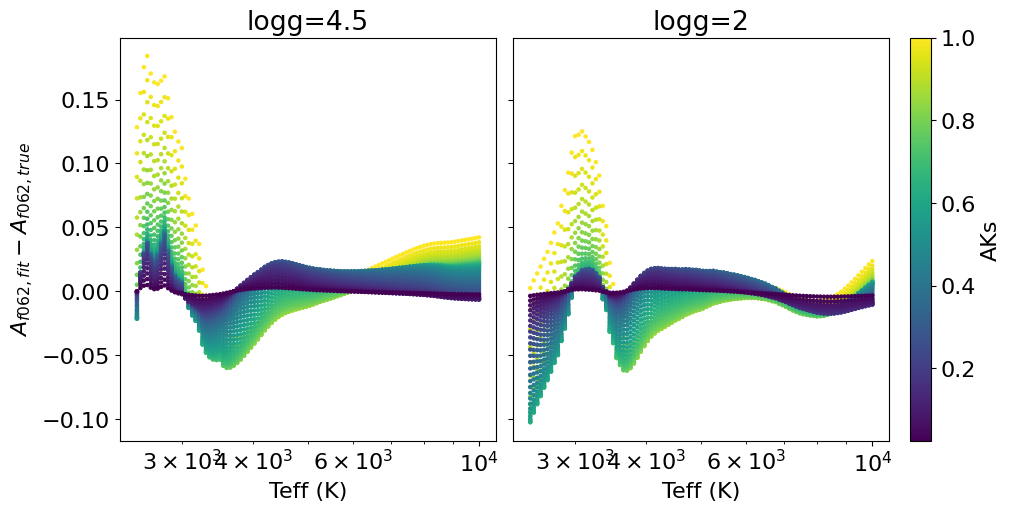

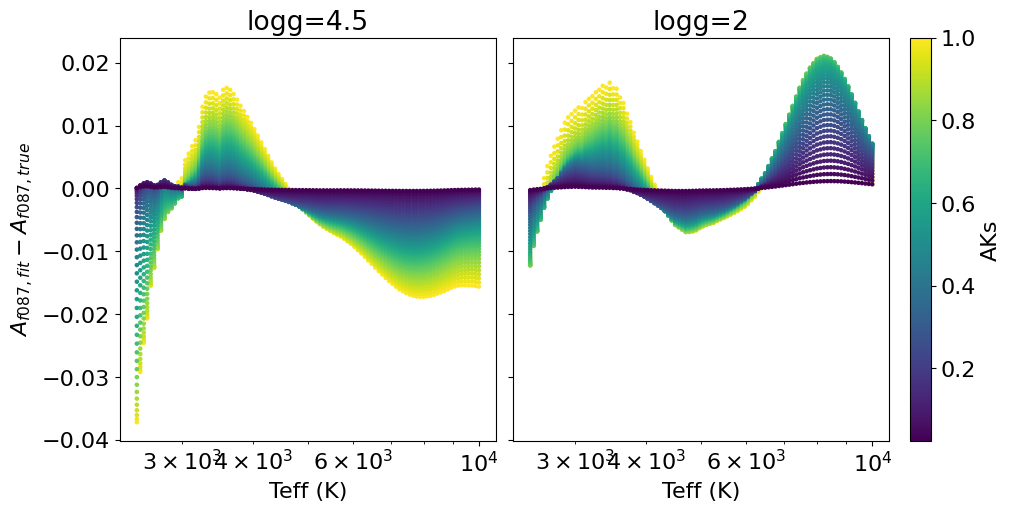

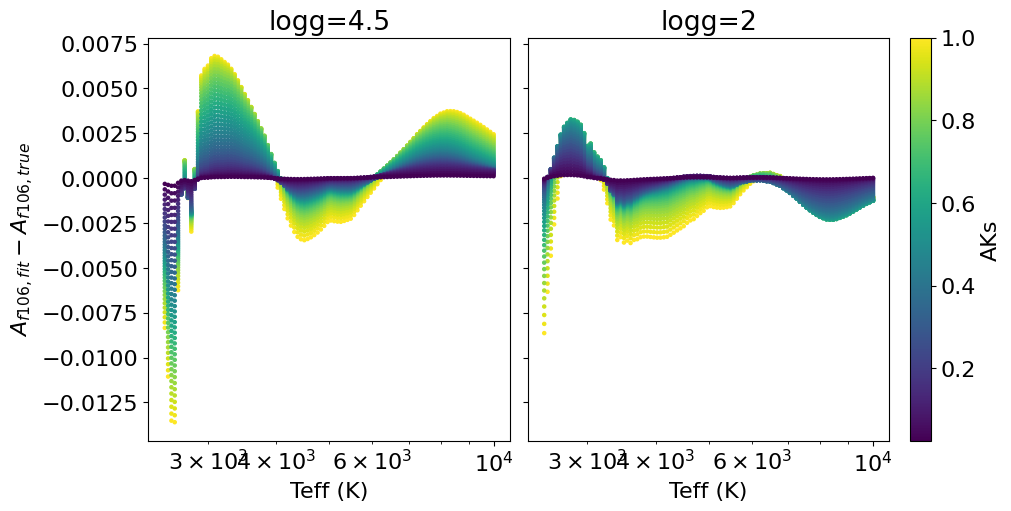

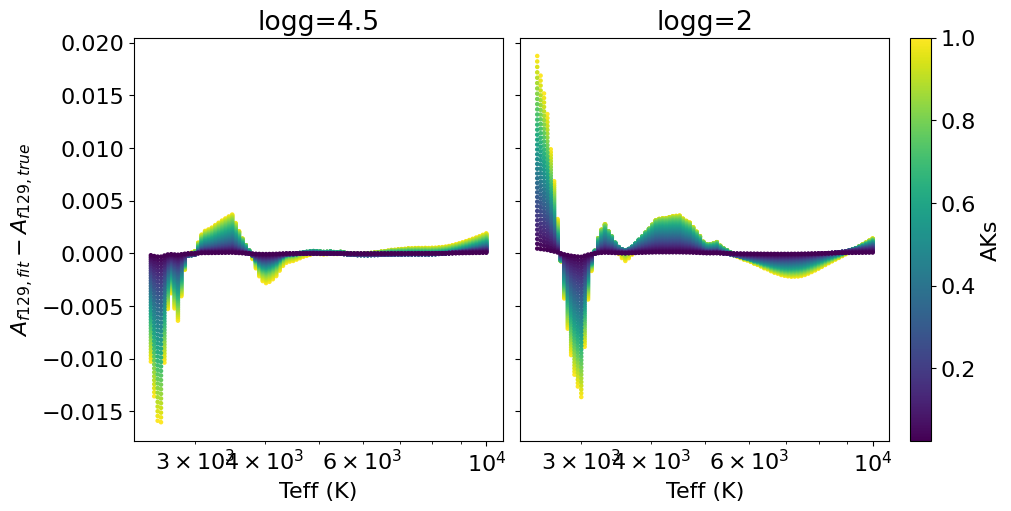

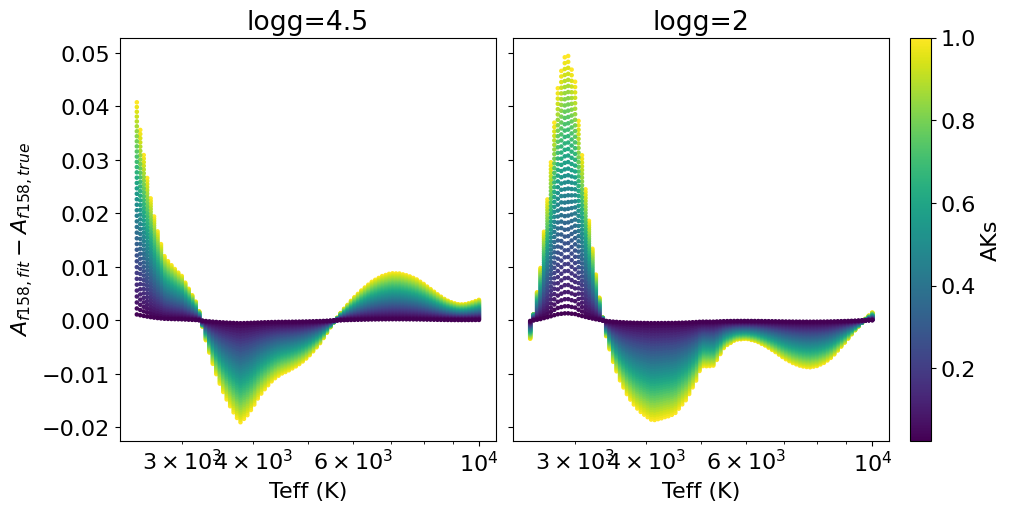

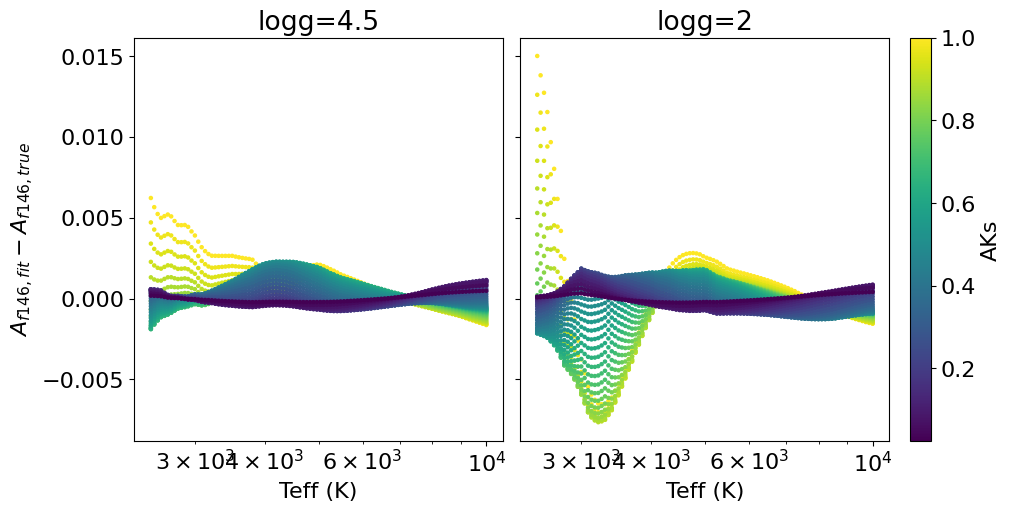

In [11]:
roman_tabs = []
roman_eqs  = []
for k,v in roman_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'roman_wfi_{c1}-roman_wfi_{c2}-abs')
    ecf.run_fit(f'roman_wfi_{k}', cols, order=2)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    roman_tabs.append(ecf.print_coeffs_deluxetable())
    roman_eqs.append(ecf.print_function_latex())

### Compile these all into one table

In [12]:
all_v1_tab = ecf.combine_deluxetables(roman_tabs,include_errors=False)
print(all_v1_tab)

\begin{deluxetable}{lccccccc}
\tablecaption{Extinction coefficient fit results}
\tablehead{\colhead{ID} & \colhead{Term} & \colhead{roman\_wfi\_f062} & \colhead{roman\_wfi\_f087} & \colhead{roman\_wfi\_f106} & \colhead{roman\_wfi\_f129} & \colhead{roman\_wfi\_f158} & \colhead{roman\_wfi\_f146}}
\startdata
$a_{0}$ & $1$ & $14.80249$ & $8.18453$ & $5.28889$ & $3.35980$ & $2.07475$ & $3.53035$ \\
$a_{1}$ & $A_{Ks}^{1}$ & $-2.86160$ & $-0.90272$ & $-0.35889$ & $-0.14215$ & $-0.05282$ & $-1.17620$ \\
$a_{2}$ & $A_{Ks}^{2}$ & $0.97662$ & $0.19127$ & $0.03713$ & $0.00722$ & $0.00181$ & $0.30357$ \\
$b_{0}$ & $C_{1}$ & $-1.02823$ & $-0.02762$ & $-0.09183$ & $0.04665$ & $0.12400$ & $-0.78511$ \\
$b_{1}$ & $C_{1}A_{Ks}$ & $0.41098$ & $0.04767$ & $0.05057$ & $0.03939$ & $-0.00401$ & $0.42112$ \\
$b_{2}$ & $C_{1}^{2}$ & $0.06412$ & $-0.02850$ & $-0.05241$ & $0.24521$ & $-0.07919$ & $0.14915$ \\
$c_{0}$ & $C_{2}$ &  -  & $-0.38860$ & $-0.20722$ & $-0.21945$ & $-0.36036$ & $-0.52846$ \\
$c_{1}$ & $C

### Save the fit results to a json file

In [13]:
import json
with open("roman_fits_abs_AKs1.json", 'w') as f:
    json.dump(fits_dict, f, indent=4)

## Performance on SynthPop catalogs

Note: this was running on SynthPop v1, which uses the MIST v1.2 isochrones. Their Roman filters are out of date, so we get some slight deviations due to the function input colors varying slightly from those integrated here. Additionally, the MIST isochrones were built on different atmospheric models.

In [49]:
#import synthpop as sp

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pydantic/_internal/_config.py:341: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)


In [14]:
# Only re-run the catalog generation if needed
if False:
    mod = sp.SynthPop('huston2025_defaults.synthpop_conf', 
                maglim=["W146", 99,"remove"],
                post_processing_kwargs=[{"name": "ProcessDarkCompactObjects","remove": True},
                                        {"name": "ConvertMistMags","conversions": {"AB": 
                                            ["R062","Z087","Y106","J129","W146","H158","F184"]}}],
                obsmag=False
               )

    mod.init_populations()

    cat_lb,_ = mod.process_location(0.5,-1.4,1e-4)
    cat_gc,_ = mod.process_location(0,0,3e-5)

In [15]:
# Only re-run the catalog extinction analysis if needed
# Only needs done once, not each time you fit a filter
if False:
    cat_lb = pd.read_csv('outputfiles/default/Huston2025_l0.500_b-1.400.csv')
    cat_lb_ext = ecf.get_catalog_true(cat_lb)
    cat_lb_ext.to_hdf('outputfiles/lb_simtab.h5',key='data', index=False)
    cat_gc = pd.read_csv('outputfiles/default/Huston2025_l0.000_b0.000.csv')
    cat_gc_ext = ecf.get_catalog_true(cat_gc)
    cat_gc_ext.to_hdf('outputfiles/gc_simtab.h5',key='data', index=False)

In [16]:
#pdb.pm()

In [17]:
cat_lb_ext = pd.read_hdf('outputfiles/lb_simtab.h5')

In [18]:
cat_lb_ext

,pop,iMass,age,Fe/H_initial,Mass,In_Final_Phase,Dist,l,b,vr_bc,...,roman_wfi_f106_roman_wfi_f129_app_spi,roman_wfi_f106_roman_wfi_f129_abs_spi,roman_wfi_f129_roman_wfi_f158_app_spi,roman_wfi_f129_roman_wfi_f158_abs_spi,roman_wfi_f158_roman_wfi_f184_app_spi,roman_wfi_f158_roman_wfi_f184_abs_spi,roman_wfi_f184_roman_wfi_f213_app_spi,roman_wfi_f184_roman_wfi_f213_abs_spi,roman_wfi_f213_roman_wfi_f146_app_spi,roman_wfi_f213_roman_wfi_f146_abs_spi
0,0.0,0.225409,10.000000,-0.302619,0.225406,0.0,3.577555,0.499926,-1.396989,-55.129752,...,0.457956,0.194622,0.282810,0.110694,0.016754,-0.073832,-0.076088,-0.136662,-0.245224,0.061219
1,0.0,0.195736,10.000000,0.093231,0.195734,0.0,4.696837,0.503415,-1.404102,30.208747,...,0.613780,0.285237,0.318038,0.091552,0.024833,-0.089713,-0.005202,-0.085796,-0.378190,0.004509
2,0.0,0.722135,10.000000,0.186282,0.722076,0.0,4.783169,0.505146,-1.401997,95.448354,...,0.504611,0.142894,0.361272,0.131743,0.036176,-0.086688,-0.147052,-0.227409,-0.239043,0.168849
3,0.0,0.130571,10.000000,0.194754,0.130570,0.0,4.984253,0.499826,-1.400297,-14.915958,...,0.708139,0.371070,0.336552,0.086780,0.015225,-0.103517,0.054262,-0.034827,-0.459490,-0.059103
4,0.0,0.160969,10.000000,0.044383,0.160967,0.0,5.044873,0.497311,-1.398311,-104.416600,...,0.656811,0.287573,0.350059,0.095480,0.037118,-0.091630,0.005423,-0.085365,-0.423096,0.002661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61357,10.0,0.114034,8.507044,-0.517469,0.114033,0.0,24.361235,0.500215,-1.395980,-48.518570,...,0.869260,0.261764,0.526681,0.119642,0.117488,-0.094409,0.030058,-0.116250,-0.624798,0.030689
61358,10.0,0.233895,8.014992,-0.270726,0.233892,0.0,24.579187,0.497375,-1.399698,13.591855,...,0.850855,0.195166,0.543157,0.110575,0.153702,-0.073839,0.017657,-0.136311,-0.642435,0.060745
61359,10.0,0.281067,8.369528,-0.595814,0.281062,0.0,24.646248,0.502363,-1.403260,-12.891581,...,0.796905,0.171832,0.516600,0.108498,0.150378,-0.066519,-0.007720,-0.151841,-0.594419,0.079506
61360,10.0,0.273337,9.605614,-0.191679,0.273333,0.0,24.682933,0.496117,-1.399432,-20.699580,...,0.884473,0.196609,0.565857,0.111053,0.165720,-0.073078,0.026398,-0.135624,-0.674236,0.058610


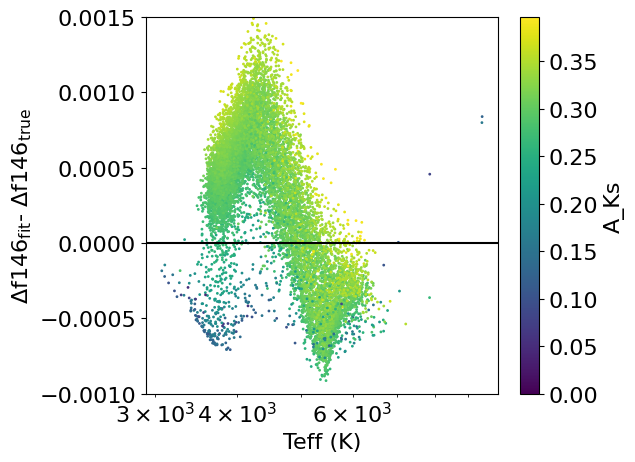

In [20]:
fig = ecf.plot_catalog_results(cat_lb_ext,maglim=25,ext='_lb')
fig.xscale('log')
fig.ylim(-0.001,0.0015)
fig.savefig('figures_lowext/ext_cat_test_f146_lb.png')

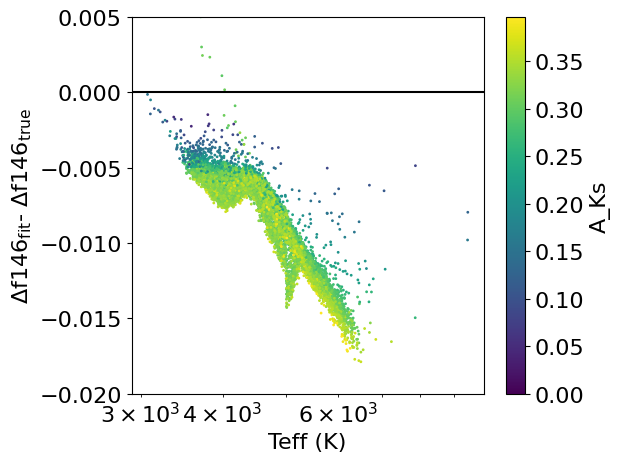

In [22]:
fig = ecf.plot_catalog_results(cat_lb_ext,maglim=25,ext='_lb', use_syn=True)
fig.xscale('log')
plt.ylim(-0.02,0.005)
fig.savefig('figures_lowext/ext_cat_test_f146_lb_sp.png')

# Euclid

In [23]:
# Set up which colors to use for which fits
euclid_fits = {'euclid_vis': ['roman_wfi_f062-roman_wfi_f087'], 
               'euclid_Y': ['euclid_Y-euclid_J'], 
               'euclid_J': ['euclid_Y-euclid_J','euclid_J-euclid_H'], 
               'euclid_H': ['euclid_J-euclid_H']}

euclid_vis 0.014747403782130674
euclid_Y 0.020354146461667572
euclid_J 0.01864633172352545
euclid_H 0.011646648442631208


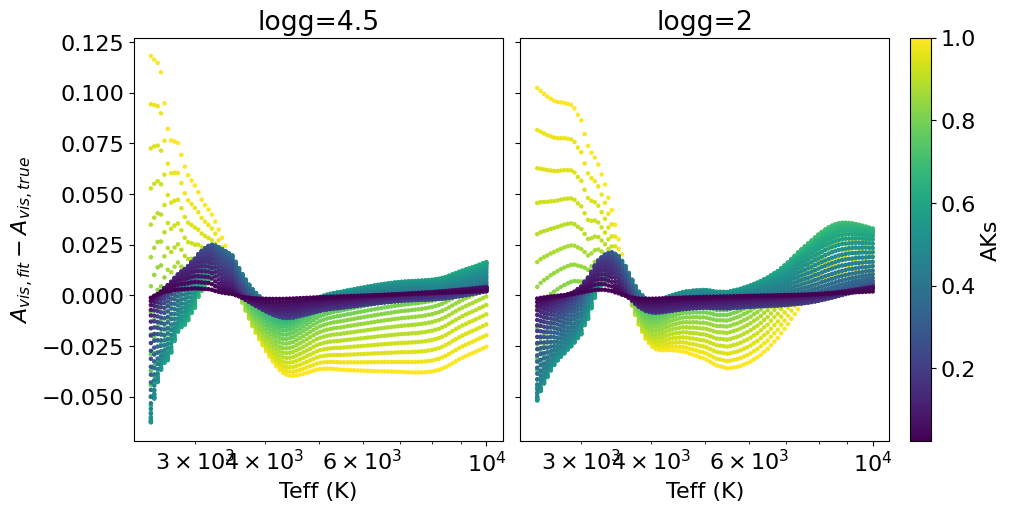

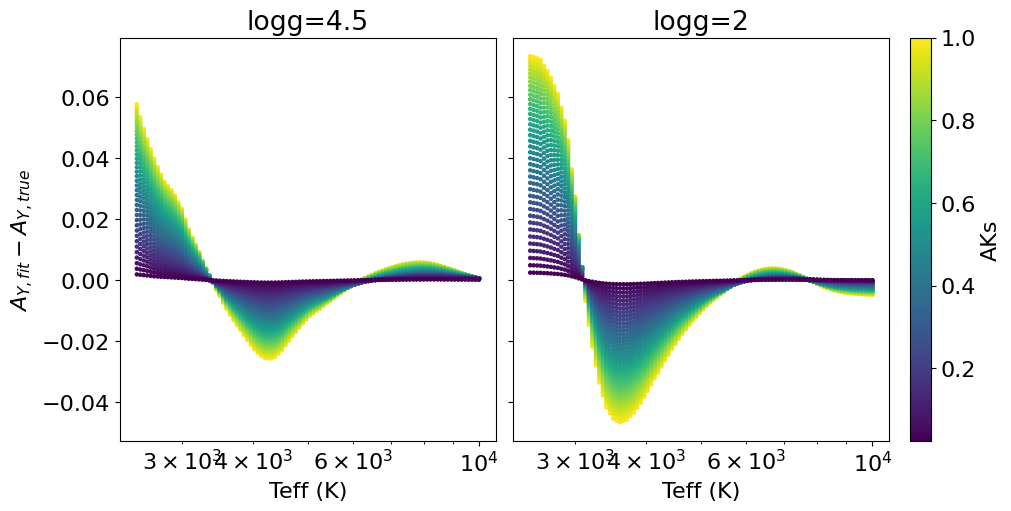

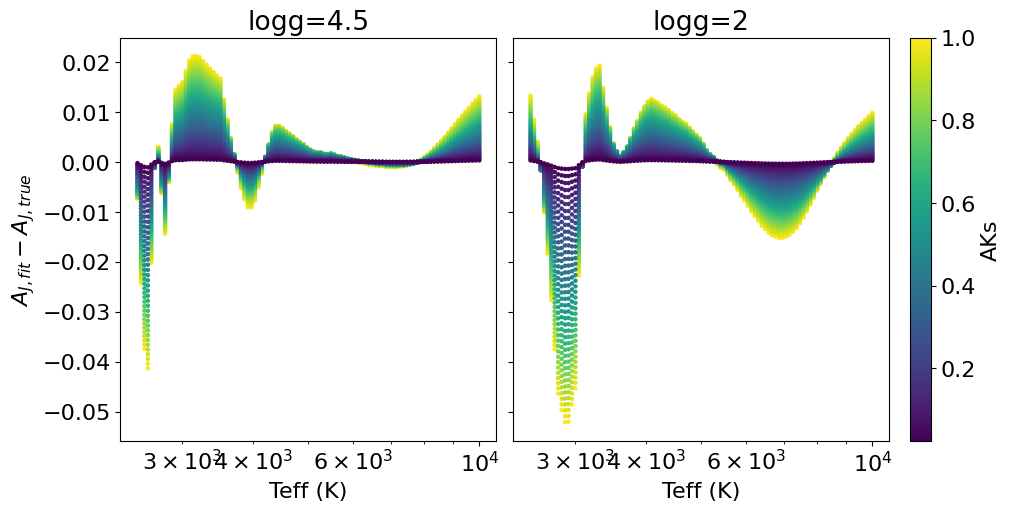

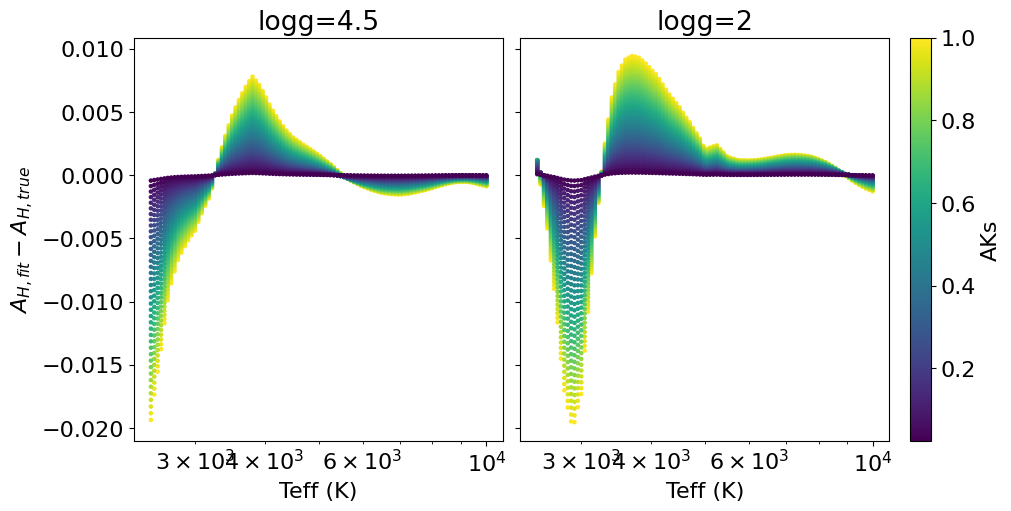

In [24]:
euclid_tabs = []
for k,v in euclid_fits.items():
    cols = []
    for c in v:
        cols.append(f'{c}-abs')
    ecf.run_fit(f'{k}', cols, order=2)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    euclid_tabs.append(ecf.print_coeffs_deluxetable())

# DECam

In [25]:
# Set up which colors to use for which fits
decam_fits = {'u': ['u-g', 'g-r', 'r-i'], 
              'g': ['u-g', 'g-r', 'r-i'], 
              'r': ['g-r', 'r-i'], 
              'i': ['r-i', 'i-z'], 
              'z': ['i-z', 'z-Y'],
              'Y': ['z-Y']}

decam_u 0.30956483557990977
decam_g 0.3188483460178152
decam_r 0.049163037743839226
decam_i 0.010720589431777556
decam_z 0.00843448645031268
decam_Y 0.02130481004974715


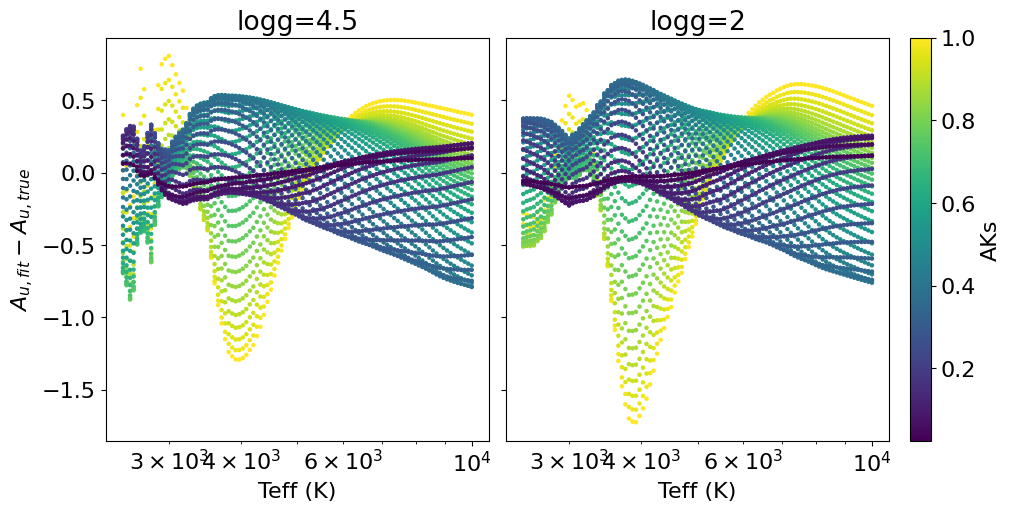

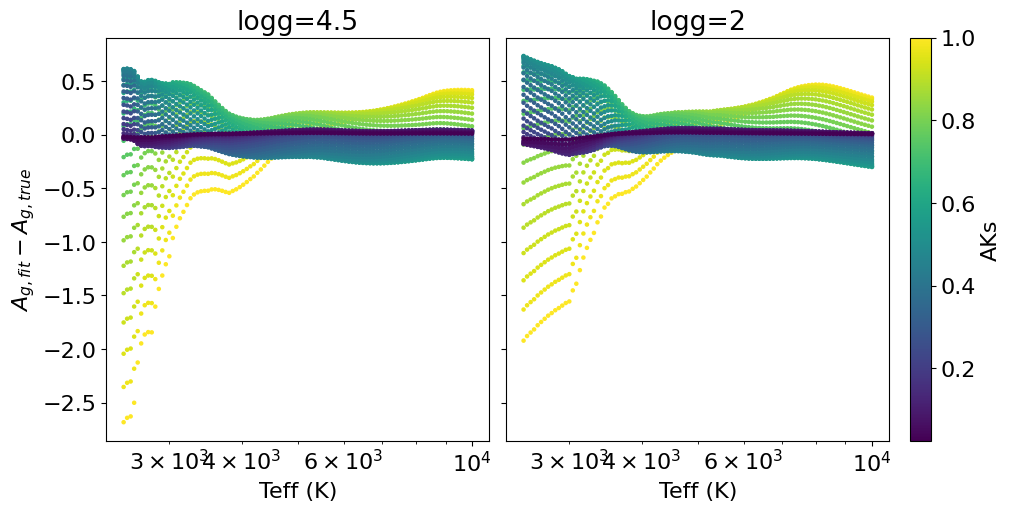

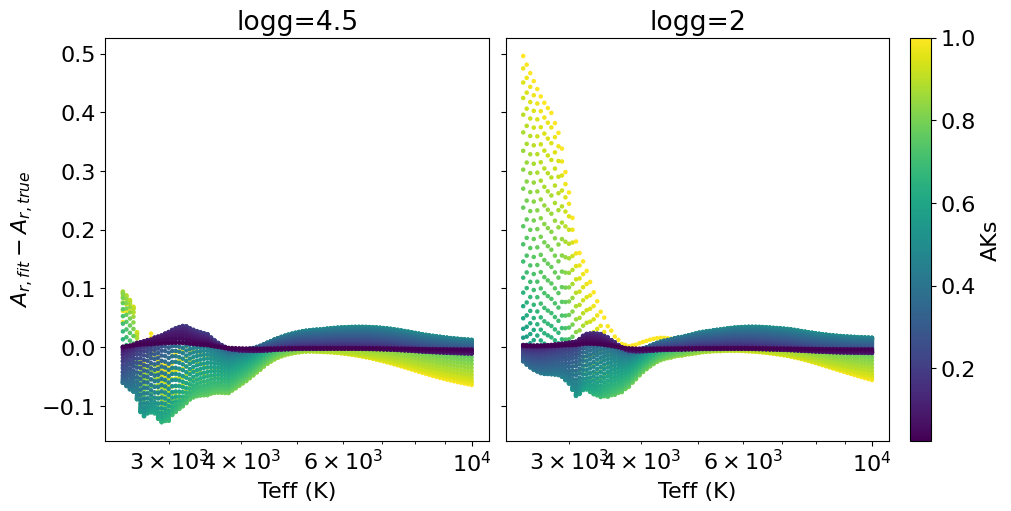

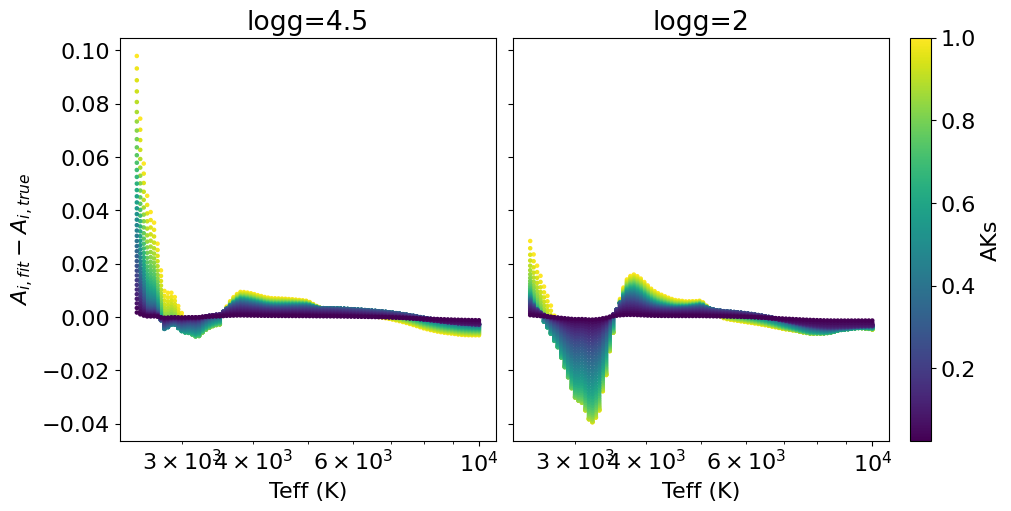

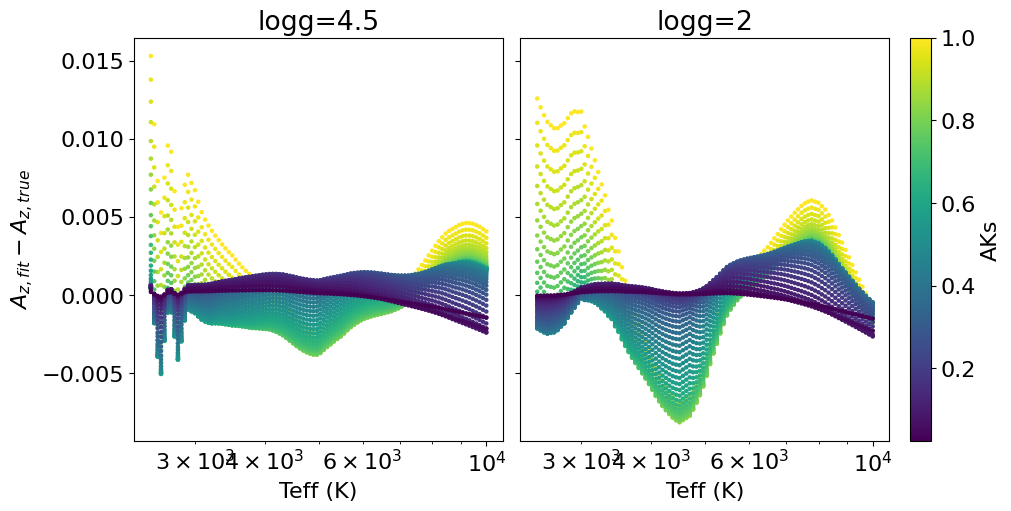

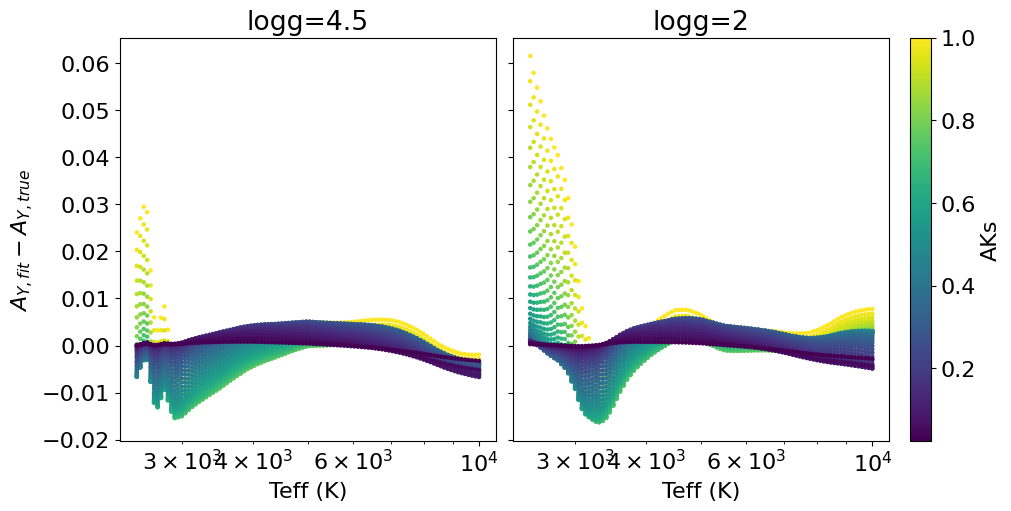

In [26]:
decam_tabs = []
for k,v in decam_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'decam_{c1}-decam_{c2}-abs')
    ecf.run_fit(f'decam_{k}', cols, order=2)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    decam_tabs.append(ecf.print_coeffs_deluxetable())

# Gaia

In [27]:
# Set up which colors to use for which fits
gaia_fits = {'G':['G-Gbp','Gbp-Grp'],
             'Gbp':['G-Gbp','Gbp-Grp'],
             'Grp':['G-Gbp','Gbp-Grp']}

gaia_dr2_rev_G 0.06971451058505623
gaia_dr2_rev_Gbp 0.03451171641948448
gaia_dr2_rev_Grp 0.01824737036382383


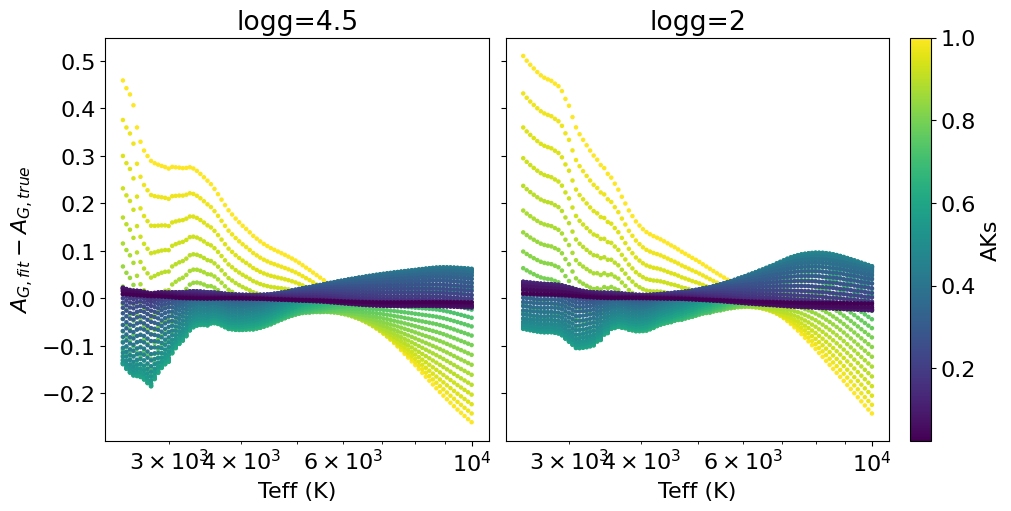

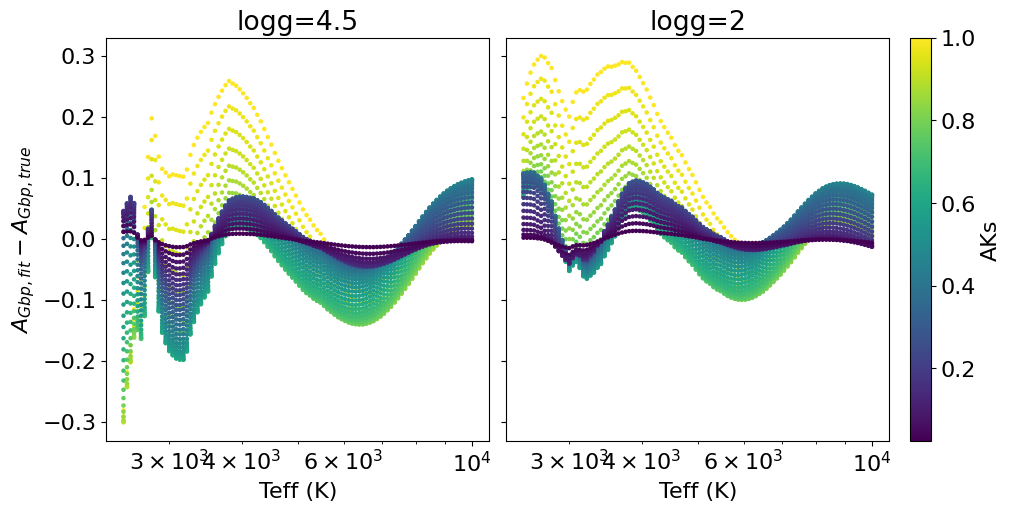

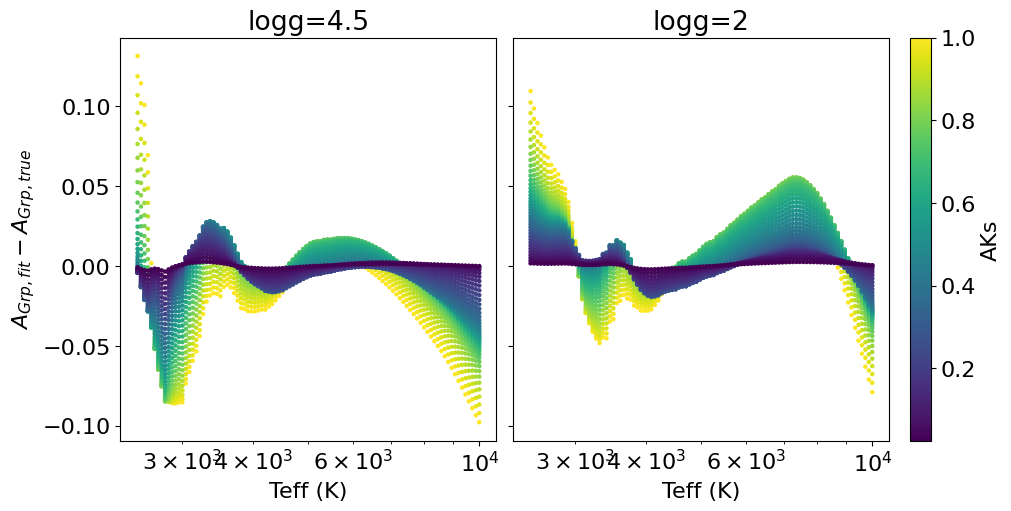

In [28]:
gaia_tabs = []
for k,v in gaia_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'gaia_dr2_rev_{c1}-gaia_dr2_rev_{c2}-abs')
    ecf.run_fit(f'gaia_dr2_rev_{k}', cols, order=2)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    gaia_tabs.append(ecf.print_coeffs_deluxetable())

# Rubin

In [29]:
# Set up which colors to use for which fits
rubin_fits = {'u': ['u-g', 'g-r', 'r-i'], 
              'g': ['u-g', 'g-r'], 
              'r': ['g-r', 'r-i'], 
              'i': ['r-i', 'i-z'], 
              'z': ['i-z', 'z-y'],
              'y': ['z-y']}

rubin_u 0.3751190241923516
rubin_g 0.02543814287556813
rubin_r 0.0048363509656577566
rubin_i 0.0036613262436531804
rubin_z 0.0025207914880217585
rubin_y 0.003745982640868392


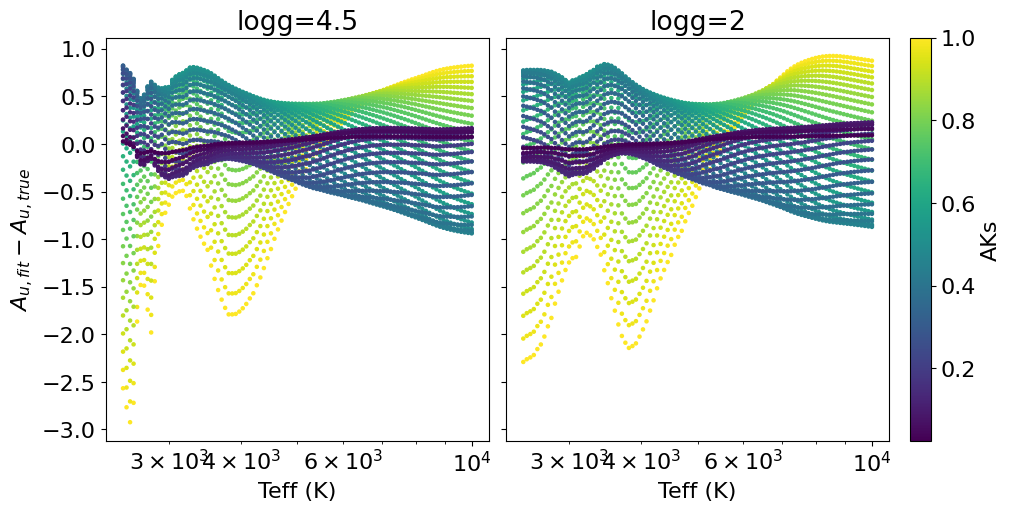

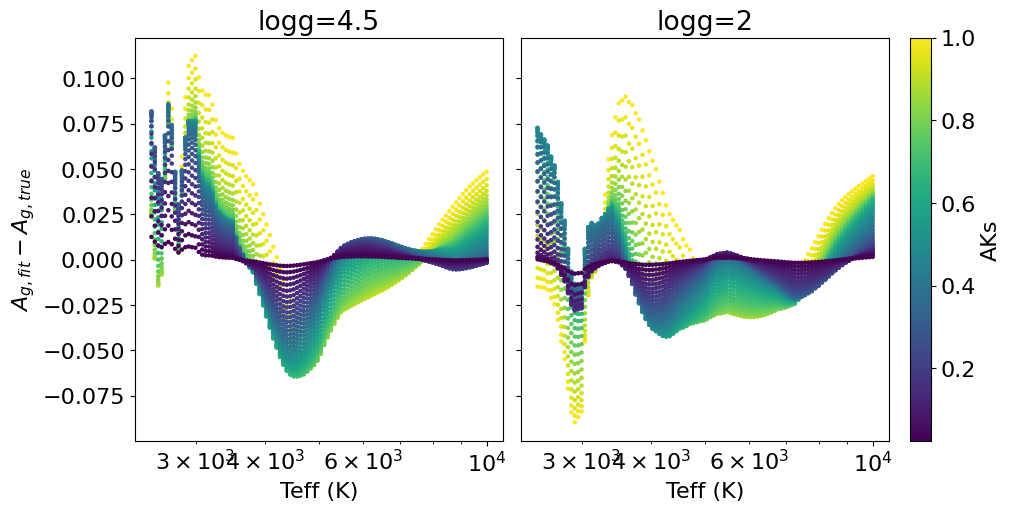

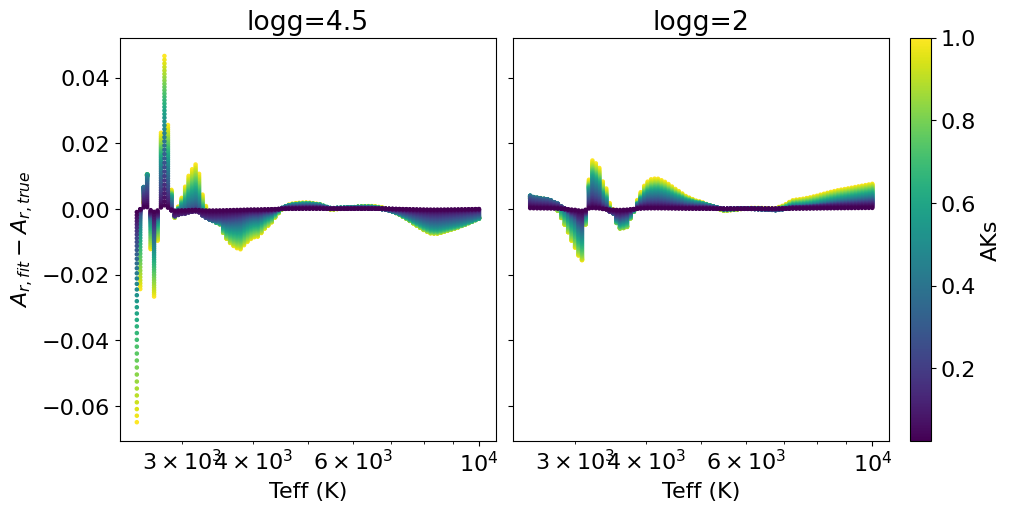

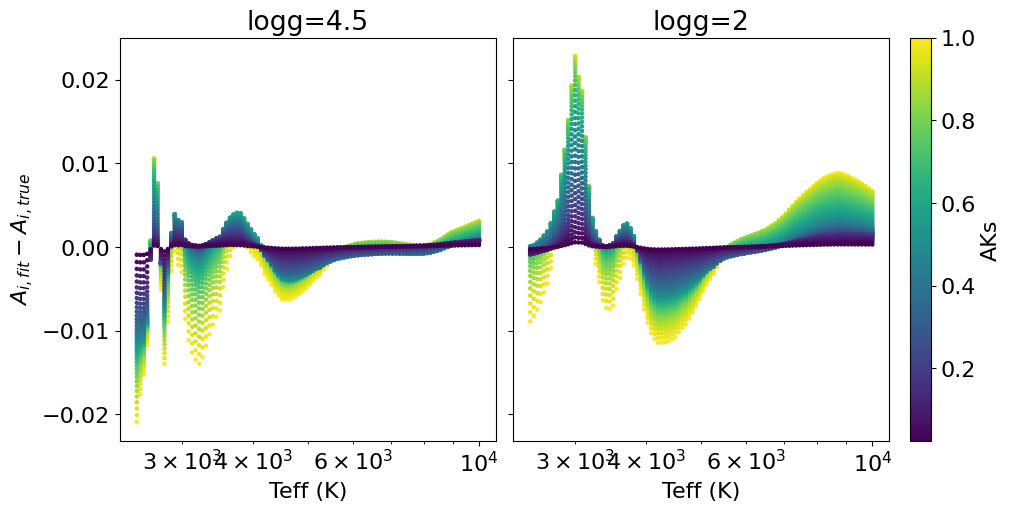

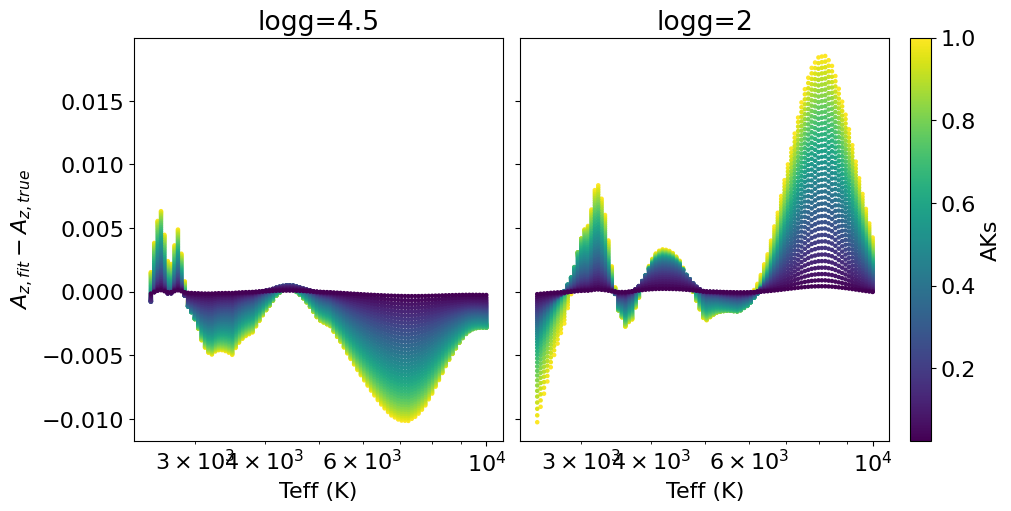

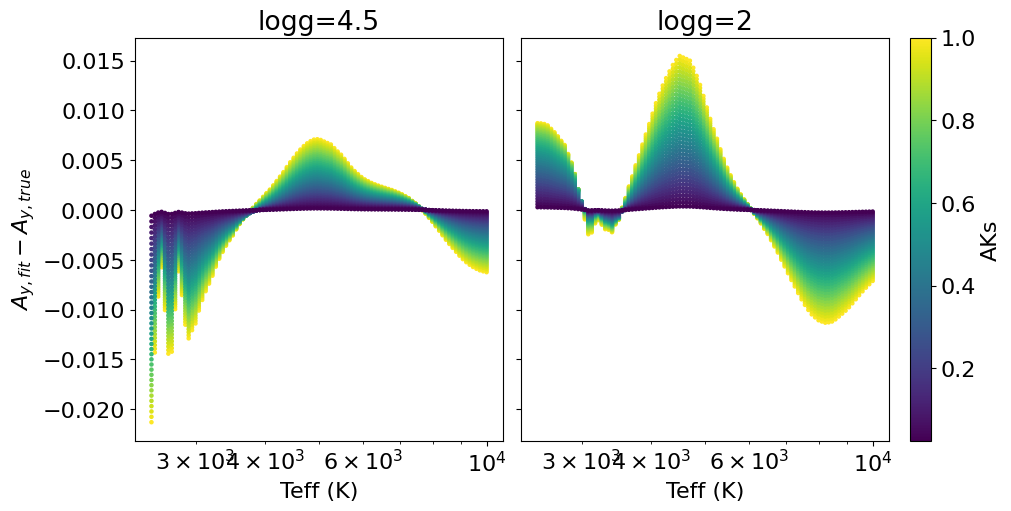

In [30]:
rubin_tabs = []
for k,v in rubin_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'rubin_{c1}-rubin_{c2}-abs')
    ecf.run_fit(f'rubin_{k}', cols, order=2)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    rubin_tabs.append(ecf.print_coeffs_deluxetable())

# HST

In [31]:
# Set up which colors to use for which fits
hst_fits = {'wfc3_uvis1_f606w': ['wfc3_uvis1_f606w-wfc3_uvis1_f814w'],
            'wfc3_uvis1_f814w': ['wfc3_uvis1_f606w-wfc3_uvis1_f814w'],
            'wfc3_ir_f098m': ['wfc3_ir_f098m-wfc3_ir_f139m']
           }

wfc3_uvis1_f606w 0.03491132411825347
wfc3_uvis1_f814w 0.014004288034887014
wfc3_ir_f098m 0.019121681905726672


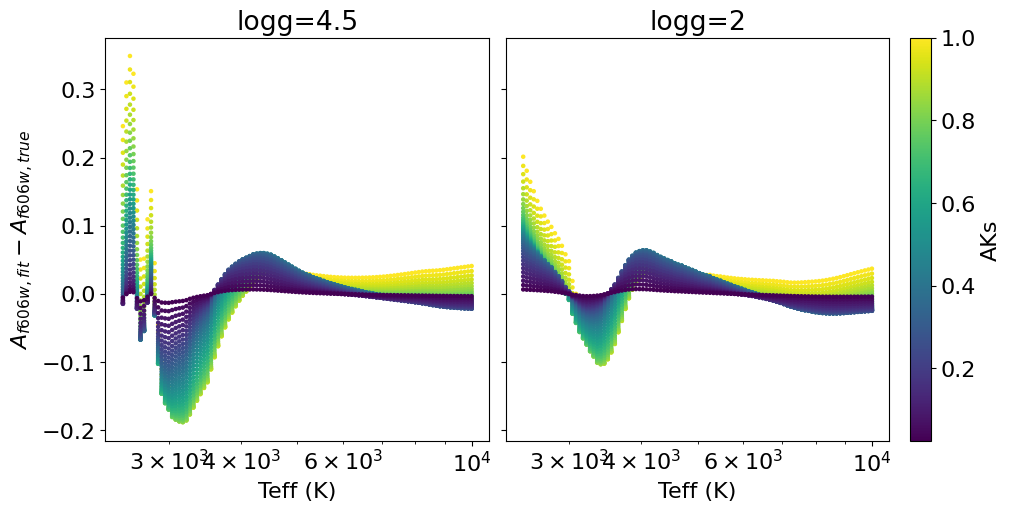

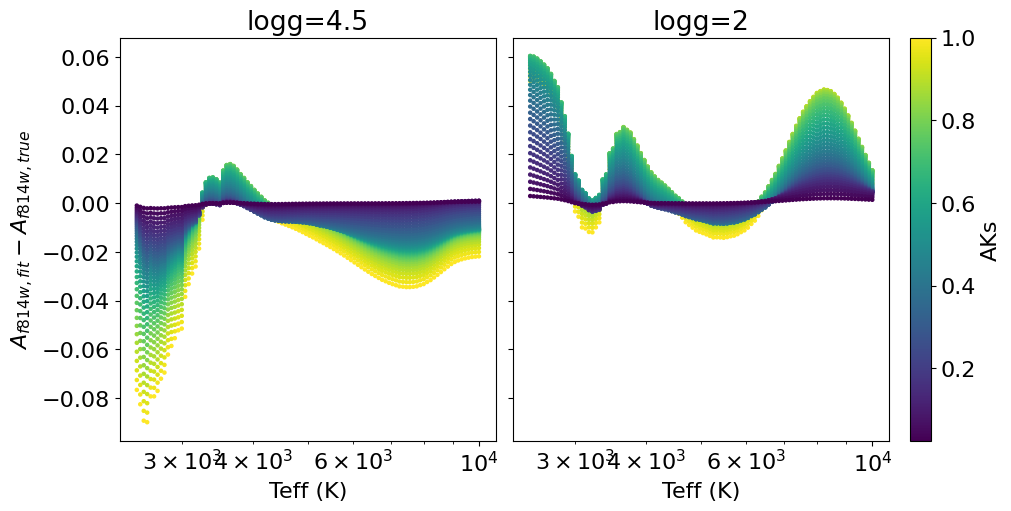

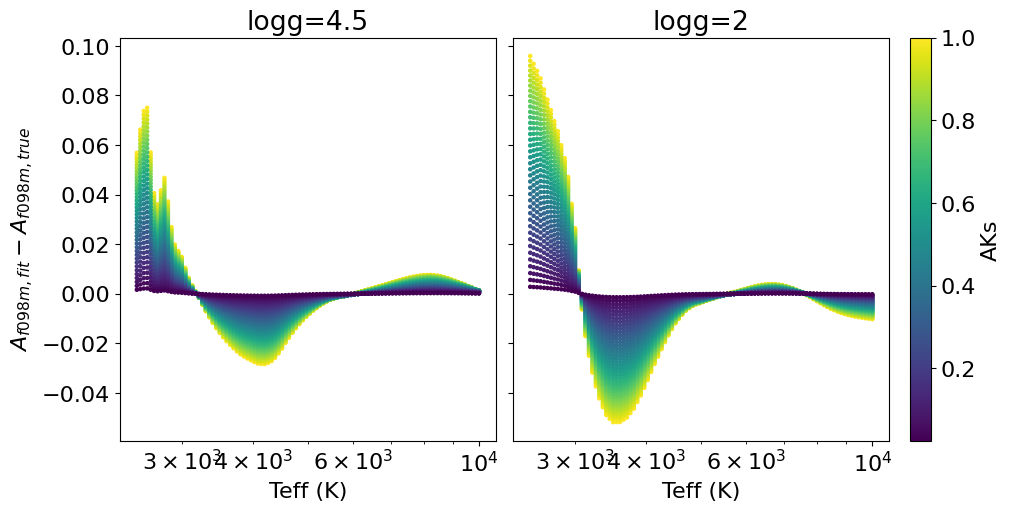

In [32]:
hst_tabs = []
for k,v in hst_fits.items():
    cols = []
    for c in v:
        cols.append(f'{c}-abs')
    ecf.run_fit(f'{k}', cols, order=2)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    hst_tabs.append(ecf.print_coeffs_deluxetable())

# JWST

In [33]:
# Set up which colors to use for which fits
jwst_fits = {'f115w': ['f115w-f140m'],
           }

jwst_f115w 0.032151755664207644


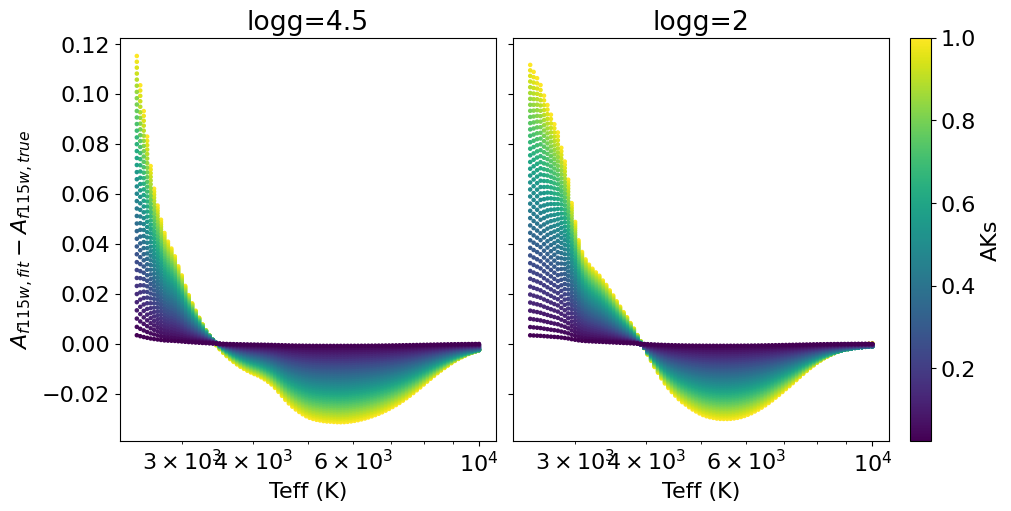

In [34]:
jwst_tabs = []
for k,v in jwst_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'jwst_{c1}-jwst_{c2}-abs')
    ecf.run_fit(f'jwst_{k}', cols, order=2)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    jwst_tabs.append(ecf.print_coeffs_deluxetable())

# Generic optical and IR

In [35]:
# Set up which colors to use for which fits
gen_opt_fits = {'U': ['U-B', 'B-V', 'V-R'], 
                'B': ['U-B', 'B-V', 'V-R'], 
                'V': ['B-V', 'V-R'], 
                'R': ['V-R', 'R-I'], 
                'I': ['R-I'], 
           }
gen_ir_fits = {'J': ['J-H'], 
                'H': ['J-H', 'H-K'], 
                'K': ['H-K'], 
           }

ubv_U 0.23521874404026438
ubv_B 0.0431262465313491
ubv_V 0.026665161075753188
ubv_R 0.022994210758594667
ubv_I 0.026115850465863608
jg_J 0.007247268792665147
jg_H 0.008470184221965093
jg_K 0.011553514603228475


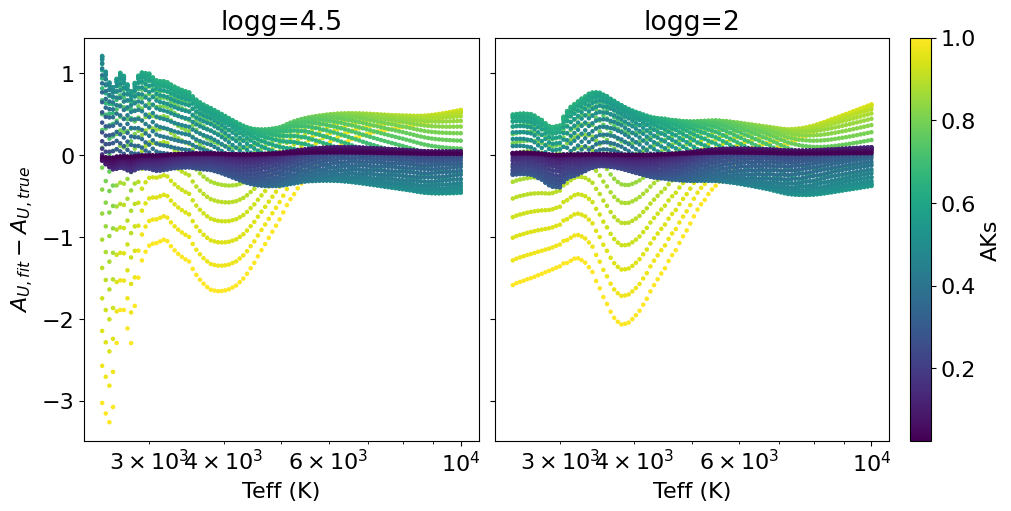

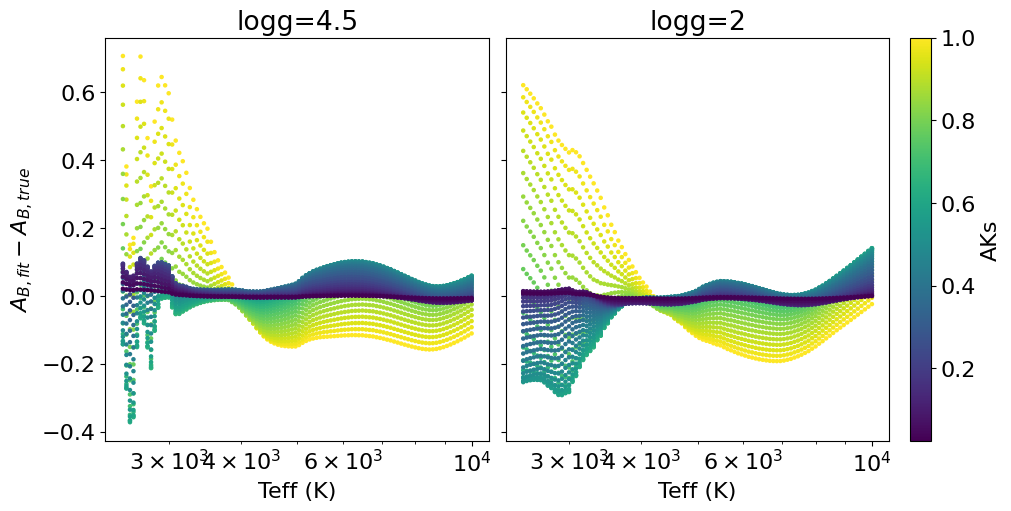

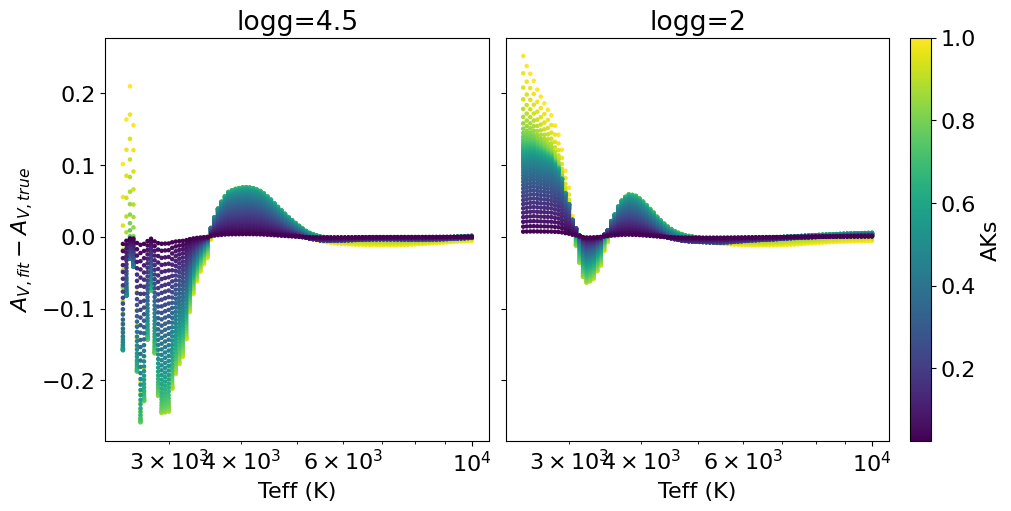

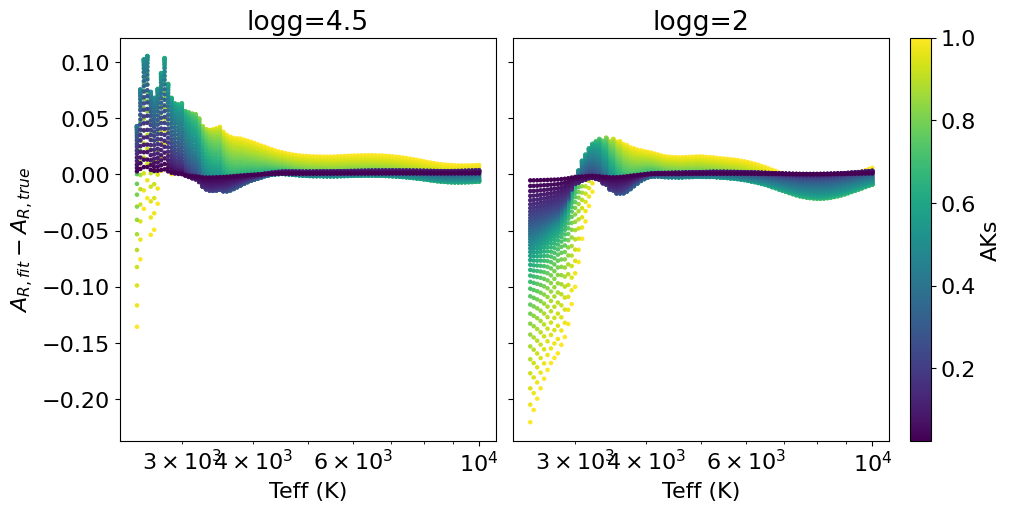

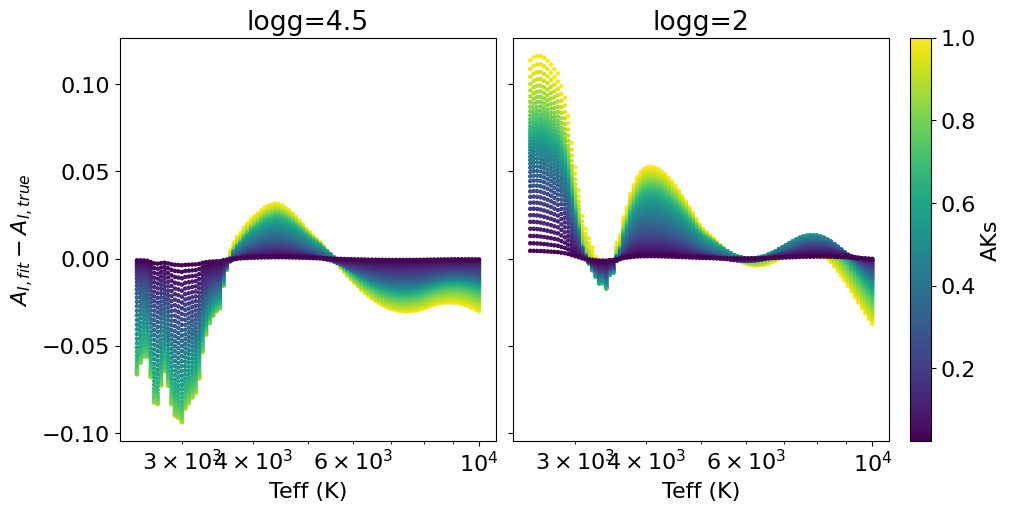

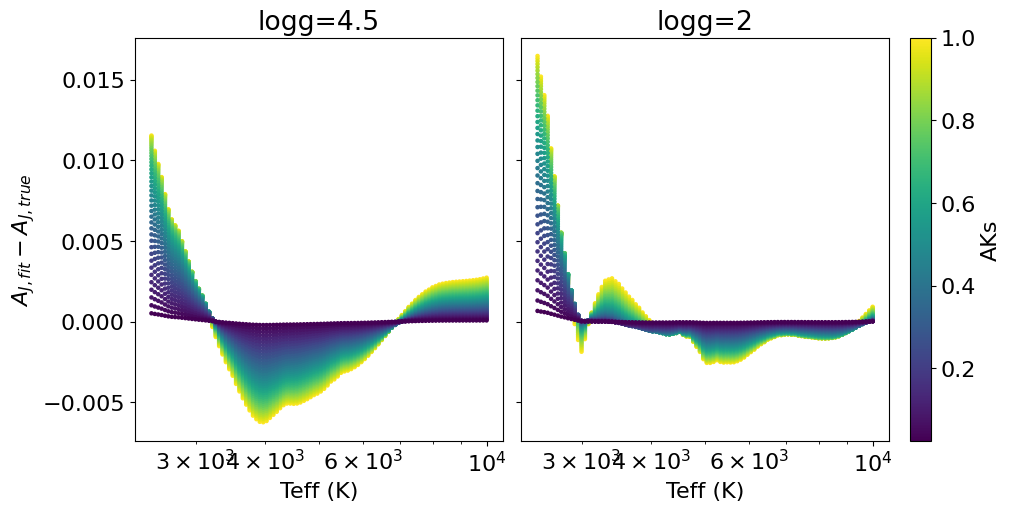

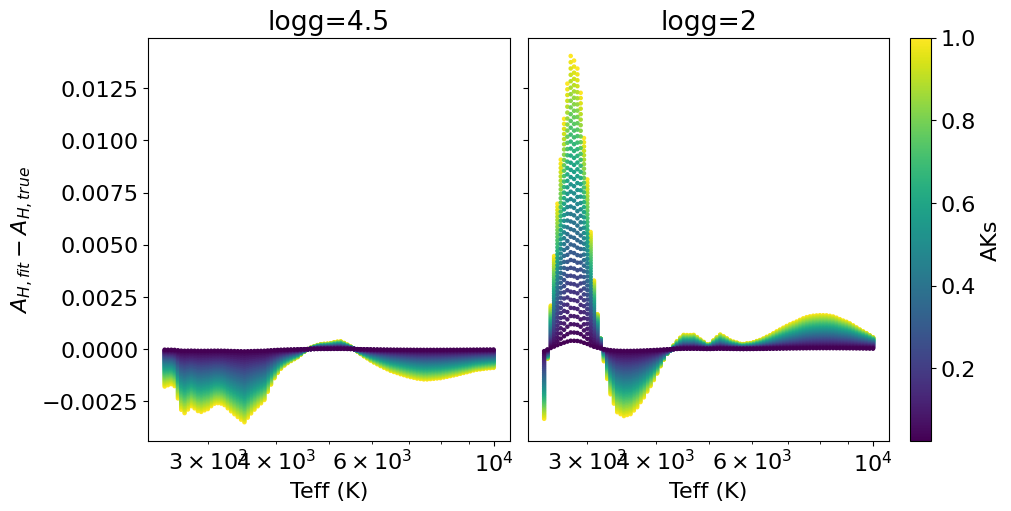

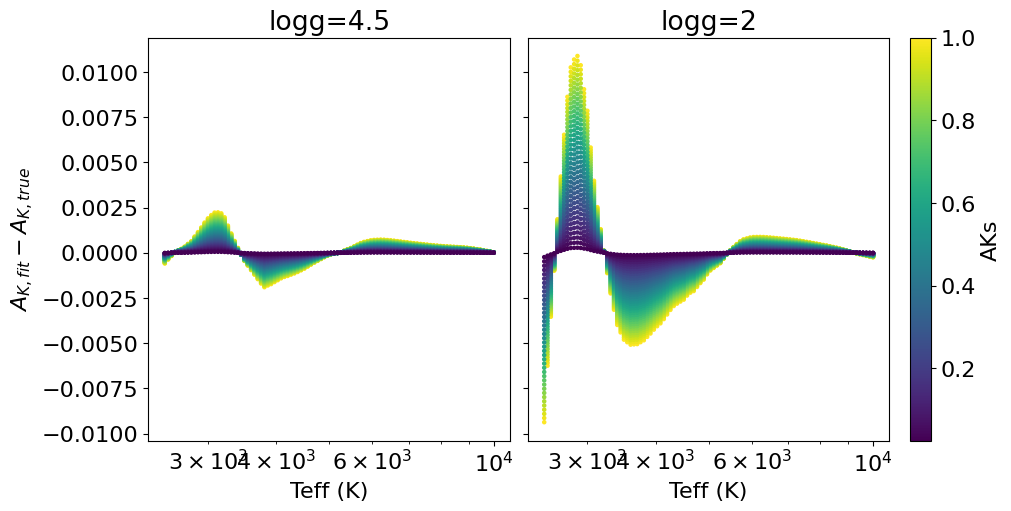

In [36]:
gen_tabs = []
for k,v in gen_opt_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'ubv_{c1}-ubv_{c2}-abs')
    ecf.run_fit(f'ubv_{k}', cols, order=2)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    gen_tabs.append(ecf.print_coeffs_deluxetable())
for k,v in gen_ir_fits.items():
    cols = []
    for c in v:
        c1,c2 = c.split('-')
        cols.append(f'jg_{c1}-jg_{c2}-abs')
    ecf.run_fit(f'jg_{k}', cols, order=2)
    fits_dict.update(ecf.get_fit_dict())
    ecf.plot_fit_result()
    gen_tabs.append(ecf.print_coeffs_deluxetable())

# New OGLE filter

ogle_Rw 0.023025950181665446


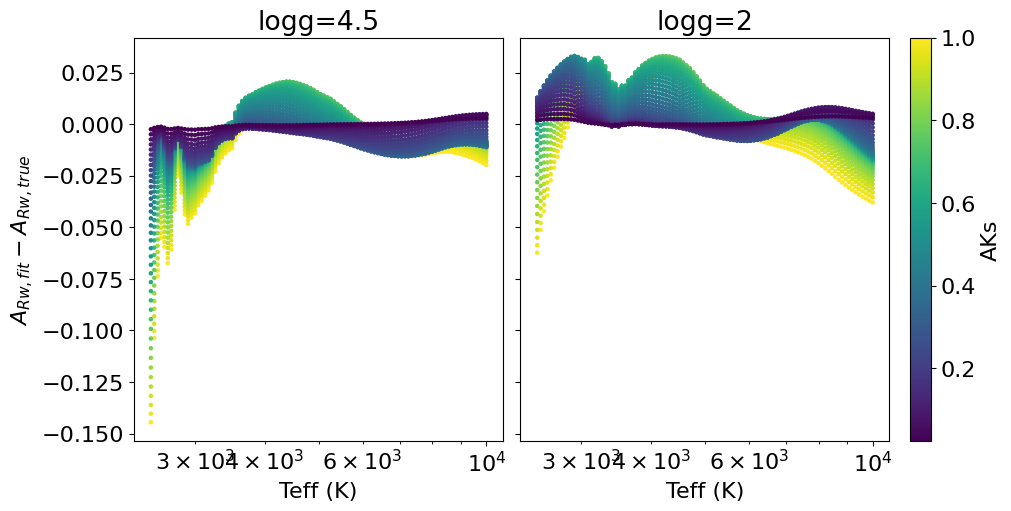

In [37]:
ecf.run_fit(f'ogle_Rw', ['roman_wfi_f062-roman_wfi_f087'], order=2)
fits_dict.update(ecf.get_fit_dict())
ecf.plot_fit_result()
ogle_tab = ecf.print_coeffs_deluxetable()

ogle_Rw 0.01904318505350256


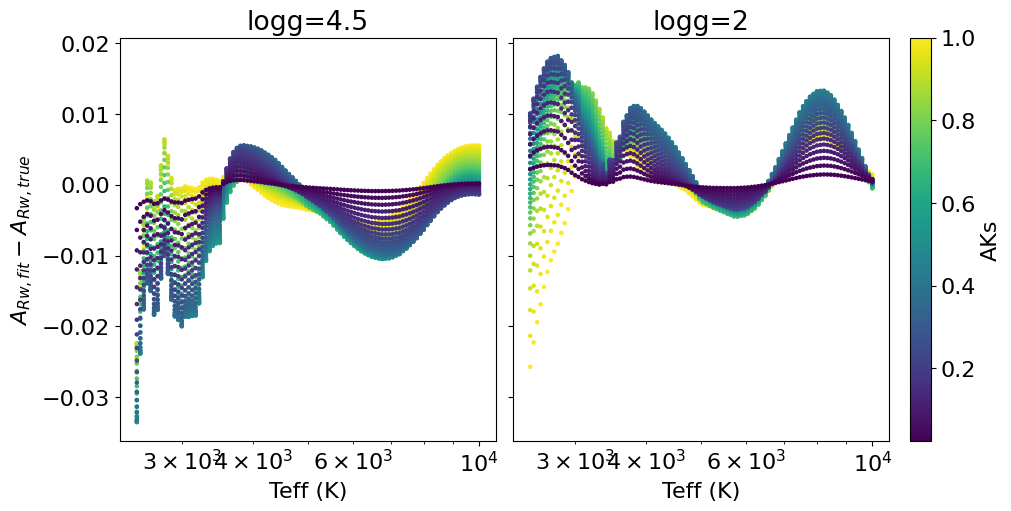

In [38]:
ecf.run_fit(f'ogle_Rw', ['ubv_R-ubv_I'], order=4)
fits_dict.update(ecf.get_fit_dict())
ecf.plot_fit_result()
ogle_tab = ecf.print_coeffs_deluxetable()